### langraph checkpoint memeory

In [2]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
load_dotenv()

c:\Users\Administrator\Downloads\b150-genaiops\18_Langchain\.venv\Lib\site-packages\langgraph\checkpoint\serde\encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


True

`InMemorySaver` is model-agnostic. It does not care whether you use Groq, Qwen, Llama, OpenAI, etc. It only stores the agent’s checkpoint/state in Python process memory so the agent can resume short-term conversation state when you invoke it with the same thread/config.

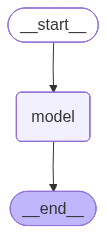

In [3]:
agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    # model="groq:qwen/qwen3-32b",
    # system_prompt="You are a helpful assistant.",
    checkpointer=InMemorySaver()
)
agent

In [5]:
## Making a thread with thread id , to maintain a session
config={"configurable":{"thread_id":"test1"}}

In [6]:
from langchain_core.messages import HumanMessage
response=agent.invoke({"messages":[HumanMessage(content="Hi my name is rakesh")]},config=config)
response

{'messages': [HumanMessage(content='Hi my name is rakesh', additional_kwargs={}, response_metadata={}, id='b8074c99-f9ca-4487-95b2-8d856be3c1e9'),
  AIMessage(content="Hello Rakesh, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 42, 'total_tokens': 70, 'completion_time': 0.045249069, 'completion_tokens_details': None, 'prompt_time': 0.003748238, 'prompt_tokens_details': None, 'queue_time': 0.037462929, 'total_time': 0.048997307}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e12a1-214f-7122-8e71-7895cbf6b7fe-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 28, 'total_tokens': 70})]}

In [7]:
# will it remmber me, how will it maintain session id --> using same config
response=agent.invoke({"messages":[HumanMessage(content="what is my name?")]},config=config)
response

{'messages': [HumanMessage(content='Hi my name is rakesh', additional_kwargs={}, response_metadata={}, id='b8074c99-f9ca-4487-95b2-8d856be3c1e9'),
  AIMessage(content="Hello Rakesh, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 42, 'total_tokens': 70, 'completion_time': 0.045249069, 'completion_tokens_details': None, 'prompt_time': 0.003748238, 'prompt_tokens_details': None, 'queue_time': 0.037462929, 'total_time': 0.048997307}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e12a1-214f-7122-8e71-7895cbf6b7fe-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 28, 'total_tokens': 70}),
  HumanMessage(content='what is my name?', additional_kwargs={}, response_

##### Another user

In [9]:
## Another users
config={"configurable":{"thread_id":"test2"}}
# response=agent.invoke({"messages":[HumanMessage(content="what is my name? ")]},config=config)
response=agent.invoke({"messages":[HumanMessage(content="Hi my name is John")]},config=config)
response

{'messages': [HumanMessage(content='what is my name? ', additional_kwargs={}, response_metadata={}, id='552d175e-f7c9-4253-831b-62a2b4ac21e6'),
  AIMessage(content="I don't know your name. I'm a large language model, I don't have the ability to know personal information about you, including your name, unless you choose to share it with me. If you'd like to share your name, I'd be happy to chat with you and use it in our conversation.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 41, 'total_tokens': 106, 'completion_time': 0.140194579, 'completion_tokens_details': None, 'prompt_time': 0.00547673, 'prompt_tokens_details': None, 'queue_time': 0.037096084, 'total_time': 0.145671309}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e12a3-f739-7f41-8c35-2e1d988f2cac-0', tool_calls=[], invalid_t

In [10]:
response=agent.invoke({"messages":[HumanMessage(content="what is my name?")]},config=config)
response

{'messages': [HumanMessage(content='what is my name? ', additional_kwargs={}, response_metadata={}, id='552d175e-f7c9-4253-831b-62a2b4ac21e6'),
  AIMessage(content="I don't know your name. I'm a large language model, I don't have the ability to know personal information about you, including your name, unless you choose to share it with me. If you'd like to share your name, I'd be happy to chat with you and use it in our conversation.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 41, 'total_tokens': 106, 'completion_time': 0.140194579, 'completion_tokens_details': None, 'prompt_time': 0.00547673, 'prompt_tokens_details': None, 'queue_time': 0.037096084, 'total_time': 0.145671309}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e12a3-f739-7f41-8c35-2e1d988f2cac-0', tool_calls=[], invalid_t